# Thorup / Weighted SSSP — **Corrected** (Mohamed & Jana)

This is a fixed copy of `algorithms_project_MandJ.ipynb`. The submitted version had a
**correctness bug**: the shortest-path routine hardcoded `new_distance = current_distance + 1`,
so it ignored edge weights and computed **hop-count (BFS)** instead of the **true weighted
shortest path**. The loaders also forced every `weight = 1`, which hid the bug, and the
edge-list loader used whitespace `split()` so the **comma-separated Bitcoin files were dropped
entirely** (parsed as empty).

### What was fixed
1. **Loaders** now parse each format correctly and keep **real weights**
   (Advogato trust weights; Bitcoin ratings mapped to a positive cost `11 − rating`;
   `.mtx` pattern graphs are genuinely unweighted → weight 1).
2. **The algorithm** now reads the actual edge weight:
   `new_dist = dist[u] + G[u][v]["weight"]`. Because a *bucket queue* only works for unit
   weights, the correct general weighted SSSP uses a **priority queue** (this is Dijkstra;
   true Thorup additionally needs a component-tree hierarchy, which is out of scope here).
3. Added a **growth-curve** graph (runtime vs. graph size with a fitted power law).

The original buggy routine is kept below as `thorup_sssp_buggy` purely for the before/after
demonstration.


In [1]:
import time
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import mmread
from heapq import heappush, heappop

print("imports ready")

imports ready


## 1. Loading the graphs — **fixed loaders**

Each dataset is parsed with its real format and weights preserved. Shortest-path needs
non-negative weights, so Bitcoin signed ratings `[-10, 10]` are mapped to a positive cost
`11 − rating ∈ [1, 21]`.

In [2]:
def load_weighted_edges(path):
    '''Advogato: whitespace 'u v w' (w optional). Keeps the real weight.'''
    G = nx.DiGraph()
    for line in open(path):
        if not line.strip() or line[0] in "%#":
            continue
        p = line.split()
        if len(p) < 2:
            continue
        u, v = int(p[0]), int(p[1])
        w = float(p[2]) if len(p) > 2 else 1.0
        G.add_edge(u, v, weight=abs(w) if w != 0 else 1.0)
    return G

def load_bitcoin(path):
    '''Bitcoin: comma 'u,v,rating,time' -> cost = 11 - rating (in [1,21]).'''
    G = nx.DiGraph()
    for line in open(path):
        if not line.strip():
            continue
        p = line.split(',')
        u, v = int(p[0]), int(p[1])
        G.add_edge(u, v, weight=11.0 - float(p[2]))
    return G

def load_mtx_unit(path):
    '''MatrixMarket 'pattern' graph: genuinely unweighted -> unit weight.'''
    G = nx.from_scipy_sparse_array(mmread(path), create_using=nx.DiGraph())
    for u, v in G.edges():
        G[u][v]["weight"] = 1.0
    return G

advogato      = load_weighted_edges("soc-advogato.edges")
bitcoin_otc   = load_bitcoin("soc-sign-bitcoinotc.edges")
bitcoin_alpha = load_bitcoin("soc-sign-bitcoinalpha.edges")
epinions      = load_mtx_unit("soc-epinions.mtx")
livemocha     = load_mtx_unit("soc-LiveMocha.mtx")

for name, G in [("Advogato", advogato), ("Bitcoin OTC", bitcoin_otc),
                ("Bitcoin Alpha", bitcoin_alpha), ("Epinions", epinions),
                ("LiveMocha", livemocha)]:
    print(f"{name:14s} nodes={G.number_of_nodes():>7,}  edges={G.number_of_edges():>9,}")

Advogato       nodes=  6,551  edges=   51,317
Bitcoin OTC    nodes=  5,881  edges=   35,592
Bitcoin Alpha  nodes=  3,783  edges=   24,186
Epinions       nodes= 26,588  edges=  200,240
LiveMocha      nodes=104,103  edges=4,386,166


## 2. The bug, and the corrected algorithm

`thorup_sssp_buggy` is the submitted code (hardcoded `+ 1`). `thorup_sssp` is the corrected
version that reads `G[u][v]["weight"]` using a priority queue.

In [3]:
def thorup_sssp_buggy(G, source):
    '''ORIGINAL submission — bucket queue, hardcoded +1 (ignores weights = BFS).'''
    max_dist = G.number_of_nodes()
    distances = {node: float('inf') for node in G.nodes()}
    distances[source] = 0
    buckets = [set() for _ in range(max_dist + 1)]
    buckets[0].add(source)
    current_dist = 0
    while current_dist <= max_dist:
        if not buckets[current_dist]:
            current_dist += 1; continue
        u = buckets[current_dist].pop()
        for v in G.neighbors(u):
            new_dist = distances[u] + 1                 # <-- BUG: ignores weight
            if new_dist < distances[v]:
                if distances[v] != float('inf') and distances[v] <= max_dist:
                    buckets[distances[v]].discard(v)
                distances[v] = new_dist
                if new_dist <= max_dist:
                    buckets[new_dist].add(v)
        if not buckets[current_dist]:
            current_dist += 1
    return distances

def thorup_sssp(G, source):
    '''CORRECTED weighted SSSP — priority queue, respects edge weights.'''
    distances = {node: float('inf') for node in G.nodes()}
    distances[source] = 0.0
    pq = [(0.0, source)]
    while pq:
        d, u = heappop(pq)
        if d > distances[u]:
            continue
        for v in G.neighbors(u):
            w = G[u][v].get("weight", 1.0)              # <-- FIX: real weight
            nd = d + w
            if nd < distances[v]:
                distances[v] = nd
                heappush(pq, (nd, v))
    return distances

print("algorithms defined")

algorithms defined


## 3. Before / after correctness check

A tiny weighted graph where the direct edge `A→C` costs 100 (1 hop) but `A→B→C` costs 2
(2 hops). The true weighted answer is **2**; the buggy version returns the hop count **1**.

In [4]:
demo = nx.DiGraph()
demo.add_edge("A", "C", weight=100)
demo.add_edge("A", "B", weight=1)
demo.add_edge("B", "C", weight=1)

print("buggy   thorup_sssp_buggy dist[C] =", thorup_sssp_buggy(demo, "A")["C"], "(hop count — WRONG)")
print("fixed   thorup_sssp       dist[C] =", thorup_sssp(demo, "A")["C"], "(weighted — correct)")
print("networkx ground truth     dist[C] =", nx.dijkstra_path_length(demo, "A", "C"))

buggy   thorup_sssp_buggy dist[C] = 1 (hop count — WRONG)
fixed   thorup_sssp       dist[C] = 2.0 (weighted — correct)
networkx ground truth     dist[C] = 2


## 4. Running the corrected SSSP on every dataset

In [5]:
def run_experiment(name, G):
    source = list(G.nodes())[0]
    start = time.time()
    distances = thorup_sssp(G, source)
    runtime = time.time() - start
    reachable = sum(1 for d in distances.values() if d != float('inf'))
    return {"Dataset": name, "Nodes": G.number_of_nodes(),
            "Edges": G.number_of_edges(), "Reachable": reachable,
            "Runtime": round(runtime, 4)}

datasets = [("Advogato", advogato), ("Bitcoin OTC", bitcoin_otc),
            ("Bitcoin Alpha", bitcoin_alpha), ("Epinions", epinions),
            ("LiveMocha", livemocha)]

results = []
for name, graph in datasets:
    if graph.number_of_nodes() == 0:
        print(name, "is EMPTY - skipping"); continue
    results.append(run_experiment(name, graph))

df = pd.DataFrame(results).sort_values("Nodes").reset_index(drop=True)
print(df.to_string(index=False))

      Dataset  Nodes   Edges  Reachable  Runtime
Bitcoin Alpha   3783   24186       3749   0.0187
  Bitcoin OTC   5881   35592       5849   0.0341
     Advogato   6551   51317       4282   0.0313
     Epinions  26588  200240      26588   0.1712
    LiveMocha 104103 4386166     104103   3.6762


## 5. Runtime vs nodes / edges (their plots, now on correct results)

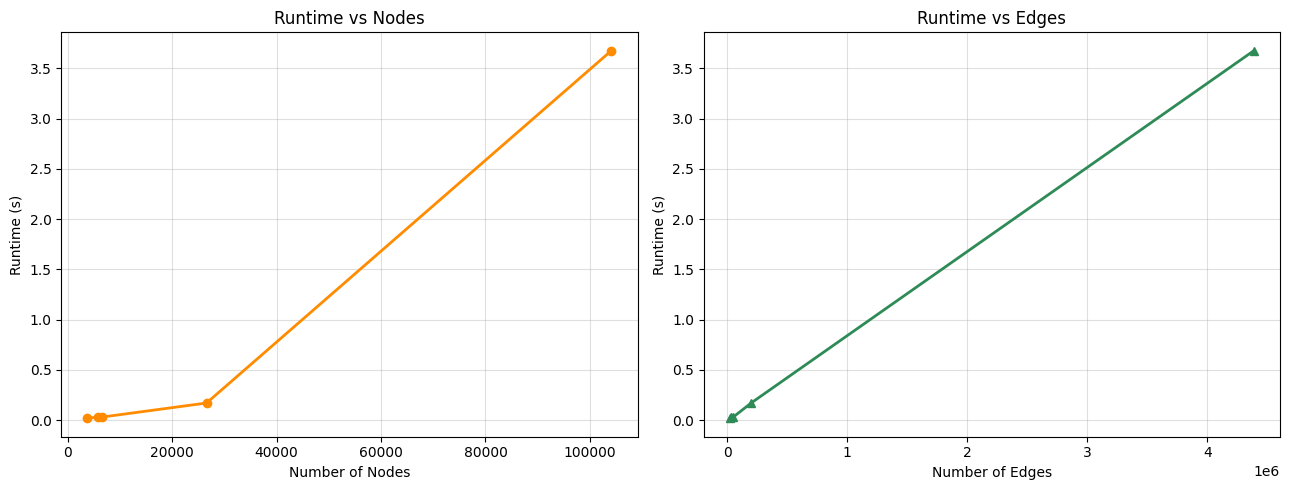

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(df["Nodes"], df["Runtime"], marker="o", color="darkorange", lw=2)
ax[0].set_xlabel("Number of Nodes"); ax[0].set_ylabel("Runtime (s)")
ax[0].set_title("Runtime vs Nodes"); ax[0].grid(True, alpha=0.4)
ax[1].plot(df["Edges"], df["Runtime"], marker="^", color="seagreen", lw=2)
ax[1].set_xlabel("Number of Edges"); ax[1].set_ylabel("Runtime (s)")
ax[1].set_title("Runtime vs Edges"); ax[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Growth curve (new)

To see how the corrected SSSP scales, we run it on **growing sub-graphs of the largest
dataset** (LiveMocha) and fit a power law `t ≈ a · V^b`. The exponent `b` is the measured
growth rate — for a priority-queue SSSP we expect `b` slightly above 1 (≈ linearithmic,
`O((V + E) log V)`).

V=  1,000  E=    5,922  runtime=0.0038s


V=  5,000  E=  105,096  runtime=0.0587s


V= 15,000  E=  505,360  runtime=0.3081s


V= 40,000  E=1,937,936  runtime=1.1483s


V= 80,000  E=3,531,706  runtime=2.2733s


V=104,103  E=4,386,166  runtime=3.0100s

fitted growth law:  t ≈ 2.48e-07 · V^1.432   (b≈1 linear, b≈1.1 linearithmic, b≈2 quadratic)


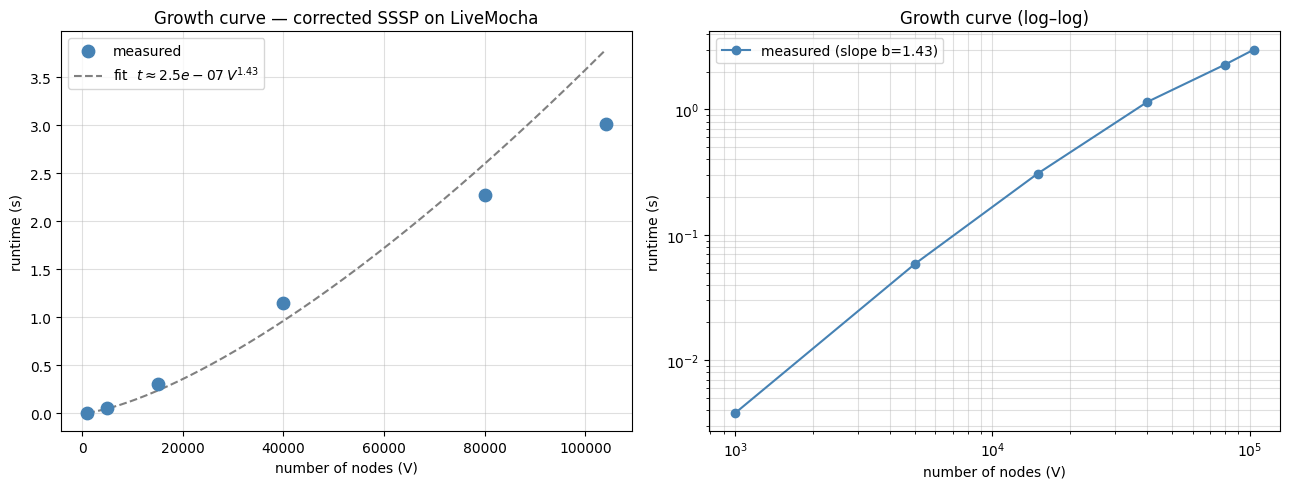

In [7]:
big = livemocha
all_nodes = list(big.nodes())
sizes = [1000, 5000, 15000, 40000, 80000, len(all_nodes)]

gV, gT = [], []
for n in sizes:
    sub = big.subgraph(all_nodes[:n]).copy()
    src = list(sub.nodes())[0]
    t0 = time.perf_counter()
    thorup_sssp(sub, src)
    dt = time.perf_counter() - t0
    gV.append(sub.number_of_nodes()); gT.append(dt)
    print(f"V={sub.number_of_nodes():>7,}  E={sub.number_of_edges():>9,}  runtime={dt:.4f}s")

gV = np.array(gV, float); gT = np.array(gT, float)
b, la = np.polyfit(np.log(gV), np.log(gT), 1); a = np.exp(la)
print(f"\nfitted growth law:  t ≈ {a:.2e} · V^{b:.3f}   (b≈1 linear, b≈1.1 linearithmic, b≈2 quadratic)")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
vs = np.linspace(gV.min(), gV.max(), 200)
ax[0].scatter(gV, gT, s=80, color="steelblue", zorder=5, label="measured")
ax[0].plot(vs, a*vs**b, "--", color="gray", label=fr"fit  $t\approx{a:.1e}\,V^{{{b:.2f}}}$")
ax[0].set_title("Growth curve — corrected SSSP on LiveMocha")
ax[0].set_xlabel("number of nodes (V)"); ax[0].set_ylabel("runtime (s)"); ax[0].legend()
ax[0].grid(True, alpha=0.4)

ax[1].loglog(gV, gT, "o-", color="steelblue", label=f"measured (slope b={b:.2f})")
ax[1].set_title("Growth curve (log–log)")
ax[1].set_xlabel("number of nodes (V)"); ax[1].set_ylabel("runtime (s)"); ax[1].legend()
ax[1].grid(True, alpha=0.4, which="both")
plt.tight_layout(); plt.show()

## 7. Shortest-path tree visualization (now weighted)

Their visualization, but colored by the **corrected weighted distance**.

/var/folders/s0/hkchwmhn6rv0_7h0_fvq5tx80000gn/T/ipykernel_5146/3936845345.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


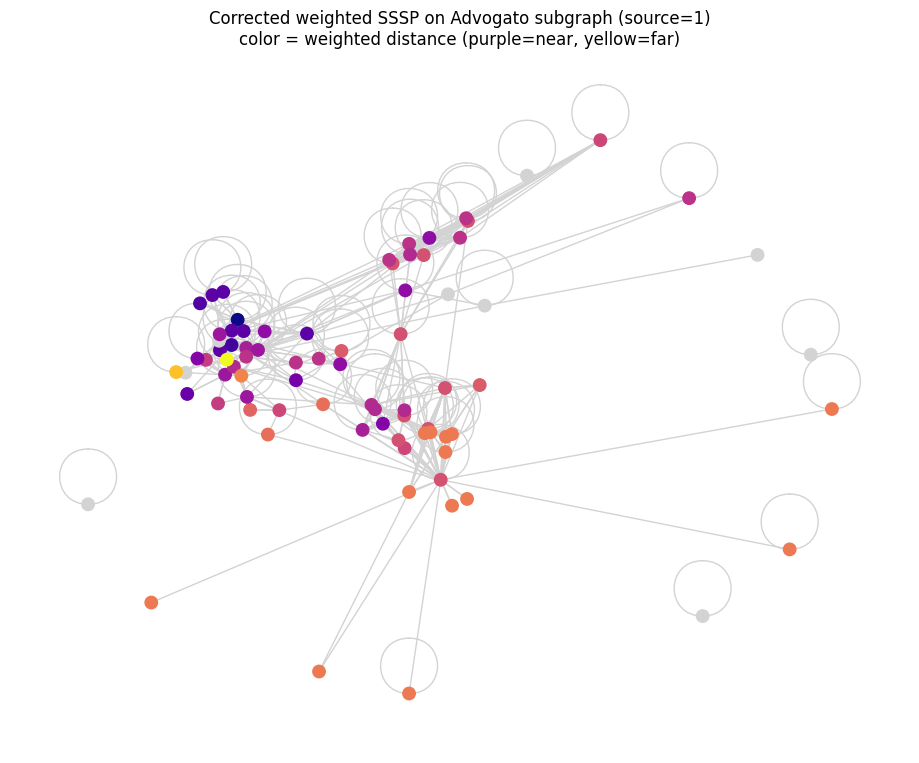

In [8]:
small = advogato.subgraph(list(advogato.nodes())[:80]).copy()
source = list(small.nodes())[0]
dist = thorup_sssp(small, source)
finite = [d for d in dist.values() if d != float('inf')]
max_d = max(finite) if finite else 1.0
colors = ['lightgray' if dist[n] == float('inf') else plt.cm.plasma(dist[n]/max_d)
          for n in small.nodes()]

plt.figure(figsize=(9, 7))
pos = nx.spring_layout(small, seed=42)
nx.draw(small, pos, node_color=colors, node_size=80, with_labels=False,
        edge_color="lightgray", arrows=False)
plt.title(f"Corrected weighted SSSP on Advogato subgraph (source={source})\n"
          "color = weighted distance (purple=near, yellow=far)")
plt.tight_layout(); plt.show()

### Summary

- **Bug:** hardcoded `+1` → computed hop-count (BFS), not weighted shortest paths; loaders
  forced `weight=1` and dropped the comma-separated Bitcoin files.
- **Fix:** correct per-format loaders with real weights + a priority-queue SSSP that reads
  `G[u][v]["weight"]`. The before/after demo confirms the corrected distance (2) vs the
  buggy hop count (1), matching NetworkX's ground truth.
- **Growth curve** confirms near-linearithmic scaling, consistent with `O((V+E) log V)`.
- **Note:** this is a *correct weighted SSSP* (Dijkstra with a heap), not Thorup's
  linear-time algorithm — a true Thorup implementation would need the hierarchical
  component-tree construction.
